In [2]:
import numpy as np                   
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression    
from sklearn.metrics import mean_absolute_error
from sklearn.neural_network import MLPRegressor

In [3]:
df = pd.read_csv('USA Housing Dataset.csv')               #read the data from file
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4140 non-null   object 
 1   price          4140 non-null   float64
 2   bedrooms       4140 non-null   float64
 3   bathrooms      4140 non-null   float64
 4   sqft_living    4140 non-null   int64  
 5   sqft_lot       4140 non-null   int64  
 6   floors         4140 non-null   float64
 7   waterfront     4140 non-null   int64  
 8   view           4140 non-null   int64  
 9   condition      4140 non-null   int64  
 10  sqft_above     4140 non-null   int64  
 11  sqft_basement  4140 non-null   int64  
 12  yr_built       4140 non-null   int64  
 13  yr_renovated   4140 non-null   int64  
 14  street         4140 non-null   object 
 15  city           4140 non-null   object 
 16  statezip       4140 non-null   object 
 17  country        4140 non-null   object 
dtypes: float

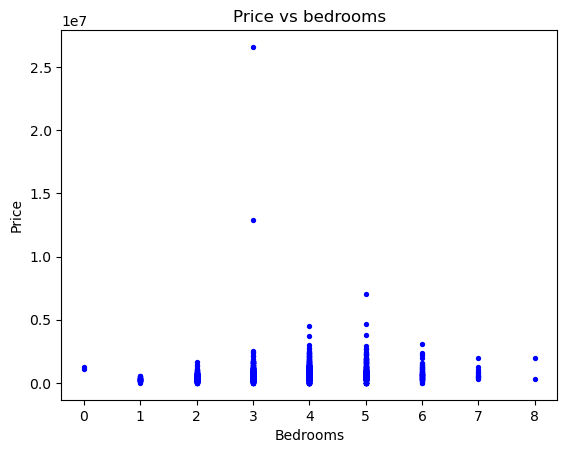

In [4]:
# I choose 8 variables which are 2,3,4,5,6,9,10,11 from the list above to plot and see how they are
# connected to the price
fig, ax1 = plt.subplots()   

# create a scatter plot of datapoints 
# each datapoint is depicted by a dot in color 'blue' and size '10'
ax1.scatter(df['bedrooms'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax1.set(xlabel='Bedrooms', ylabel='Price') #define the axes
ax1.set_title('Price vs bedrooms') # define the title of the plot    

fig.show()  # display the plot on the screen 


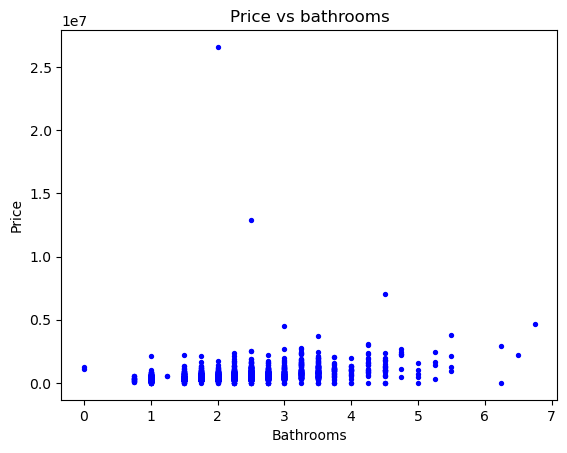

In [5]:
fig, ax2 = plt.subplots()   

ax2.scatter(df['bathrooms'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax2.set(xlabel='Bathrooms', ylabel='Price') 
ax2.set_title('Price vs bathrooms') 

fig.show()

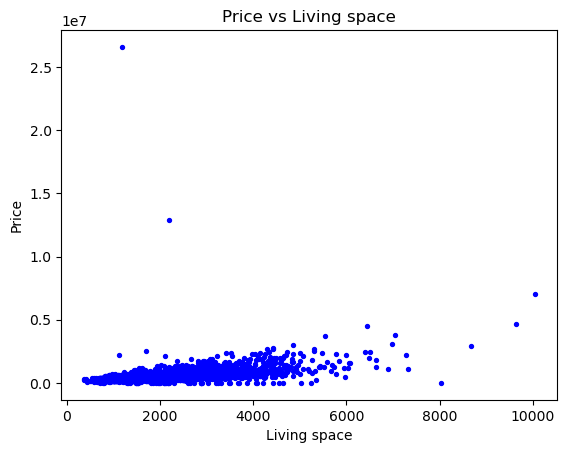

In [6]:
fig, ax3 = plt.subplots()   

ax3.scatter(df['sqft_living'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax3.set(xlabel='Living space', ylabel='Price') 
ax3.set_title('Price vs Living space') 

fig.show()

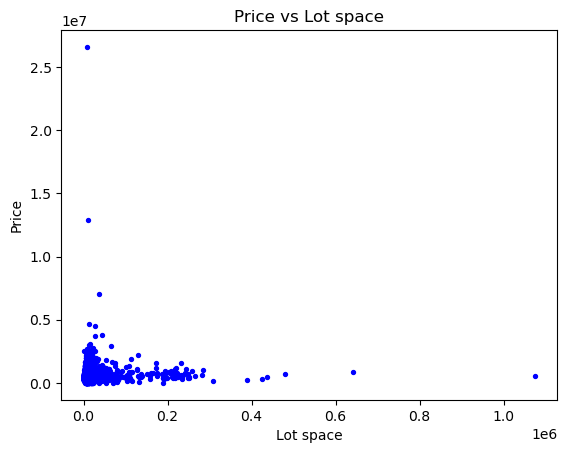

In [7]:
fig, ax4 = plt.subplots()   

ax4.scatter(df['sqft_lot'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax4.set(xlabel='Lot space', ylabel='Price') 
ax4.set_title('Price vs Lot space') 
fig.show()

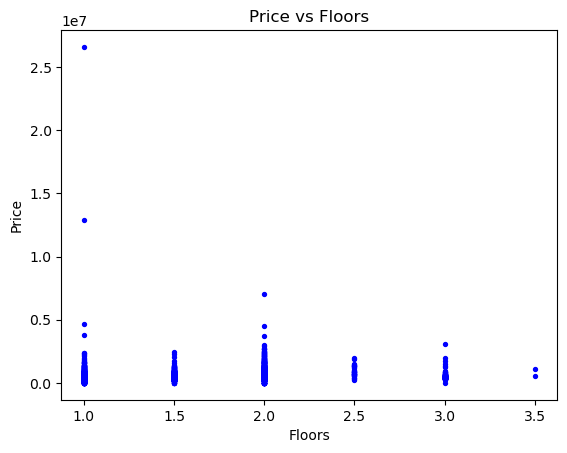

In [8]:
fig, ax5 = plt.subplots()   

ax5.scatter(df['floors'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax5.set(xlabel='Floors', ylabel='Price') 
ax5.set_title('Price vs Floors') 

fig.show()

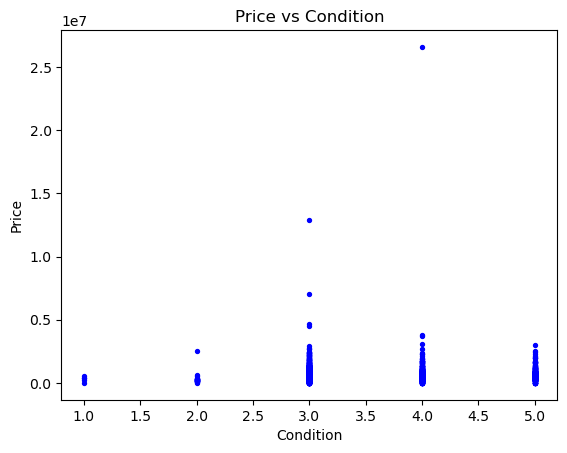

In [9]:
fig, ax6 = plt.subplots()   

ax6.scatter(df['condition'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax6.set(xlabel='Condition', ylabel='Price') 
ax6.set_title('Price vs Condition') 

fig.show()

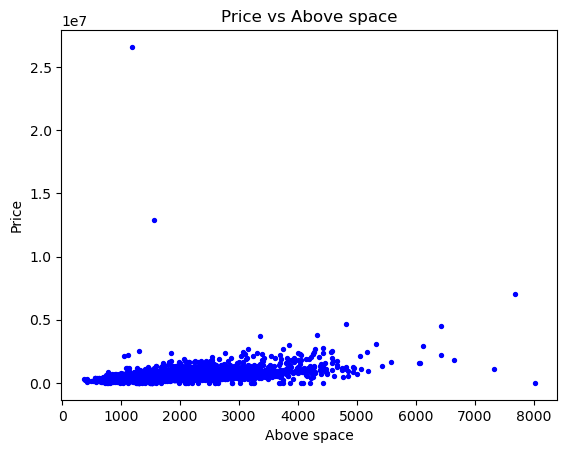

In [10]:
fig, ax7 = plt.subplots()   

ax7.scatter(df['sqft_above'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax7.set(xlabel='Above space', ylabel='Price') 
ax7.set_title('Price vs Above space') 

fig.show()

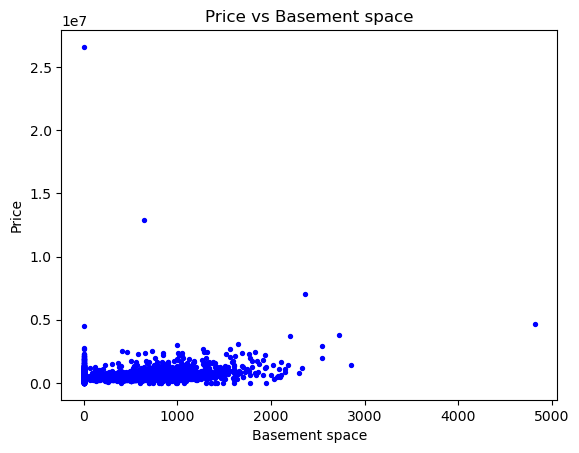

In [11]:
fig, ax8 = plt.subplots()   

ax8.scatter(df['sqft_basement'], df['price'], color='b', s=8, label='datapoints from the dataframe "newdata"') 
ax8.set(xlabel='Basement space', ylabel='Price') 
ax8.set_title('Price vs Basement space') 

fig.show()

In [12]:
data = df.drop(['date', 'waterfront', 'view', 'yr_built', 'yr_renovated', 
                'street', 'city', 'statezip', 'country', 'sqft_lot', 'floors', 'condition'],axis=1)        #clean the data for necessary data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4140 non-null   float64
 1   bedrooms       4140 non-null   float64
 2   bathrooms      4140 non-null   float64
 3   sqft_living    4140 non-null   int64  
 4   sqft_above     4140 non-null   int64  
 5   sqft_basement  4140 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 194.2 KB


In [15]:
X = data.drop(['price'], axis=1).to_numpy().reshape(-1,5)            #Choosing features and label
y = data['price'].to_numpy()
y

array([ 376000.      ,  800000.      , 2238888.      , ...,
        416904.166667,  203400.      ,  220600.      ])

In [13]:
kfold = KFold(n_splits=4, shuffle=True, random_state= 43)           #Declare kfold for later use

X_folds, X_test, y_folds, y_test = train_test_split(X, y, test_size= 0.2 ,random_state= 101682945)  #split the test data from the dataset.

In [14]:
pol_tr_errors = []
pol_val_errors = []

lin_regr = LinearRegression()

for degree in range(1,11):                      #choosing degrees for Polynomial Regression
    poly = PolynomialFeatures(degree=degree)
    tr_error = 0.0                              
    val_error = 0.0
    for i, (train, val) in enumerate(kfold.split(X_folds)):    #KFold validation and choosing validation set and training set
        X_train, y_train = X_folds[train], y_folds[train]
        X_val, y_val = X_folds[val], y_folds[val]
        
        X_train_poly = poly.fit_transform(X_train)             #Training the model
        lin_regr.fit(X_train_poly, y_train)
        y_train_pred = lin_regr.predict(X_train_poly)
        tr_error += mean_absolute_error(y_train, y_train_pred)
        
        X_val_poly = poly.fit_transform(X_val)                #Validationg the model
        y_val_pred = lin_regr.predict(X_val_poly)
        val_error += mean_absolute_error(y_val, y_val_pred)
        
    pol_tr_errors.append(tr_error / 4)                            #Average of the error estimate from KFold validation
    pol_val_errors.append(val_error / 4)
    
print(pol_tr_errors)
print(pol_val_errors)

[186993.19739953475, 185244.43010785463, 188080.52061730355, 189909.0856310002, 180383.88726492785, 185833.18185037965, 224341.00039622546, 212672.49994590002, 240164.82455914808, 231779.85671004708]
[187346.17569095048, 187119.67651227498, 196407.7523358208, 217105.58648126366, 298195.4819408711, 375210.469116806, 642143.0810408428, 2235337.509071591, 13428525.564918954, 5589924.7339983685]


In [15]:
poly = PolynomialFeatures(degree=2)    #the second degree seems to be the best for predicting the price
test_error = 0
for i, (train, val) in enumerate(kfold.split(X_folds)):   
        X_train, y_train = X_folds[train], y_folds[train]
        X_val, y_val = X_folds[val], y_folds[val]
        
        X_train_poly = poly.fit_transform(X_train)
        lin_regr.fit(X_train_poly, y_train)
        y_train_pred = lin_regr.predict(X_train_poly)
        
        X_test_poly = poly.fit_transform(X_test)          #testing the data
        y_test_pred = lin_regr.predict(X_test_poly)
        test_error += mean_absolute_error(y_test, y_test_pred)
test_error = test_error/4
print(test_error)

172307.04621519067


In [16]:
mlp_tr_errors = []
mlp_val_errors = []

for layers in range(1,11):                                           #choosing the number of layers
    
    mlp_regr = MLPRegressor(hidden_layer_sizes= tuple([15]*layers), max_iter=1000, random_state=101682945) 
    tr_error = 0.0
    val_error = 0.0
    
    for i, (train, val) in enumerate(kfold.split(X_folds)):          #KFold validation and choosing validation set and training set
        X_train, y_train = X_folds[train], y_folds[train]
        X_val, y_val = X_folds[val], y_folds[val]
        
        mlp_regr.fit(X_train, y_train)                               #Training the model
        y_train_pred = mlp_regr.predict(X_train)
        tr_error += mean_absolute_error(y_train, y_train_pred)
        
        y_val_pred = mlp_regr.predict(X_val)                         #Validationg the model
        val_error += mean_absolute_error(y_val, y_val_pred)
    
    mlp_tr_errors.append(tr_error / 4)                               #Average of the error estimate from KFold validation
    mlp_val_errors.append(val_error / 4)

print(mlp_tr_errors)
print(mlp_val_errors)

[191040.31009567695, 191283.2001665017, 191211.50278291584, 191203.07282203954, 191170.87327096862, 191080.78236644118, 190154.24992993142, 191602.46420388803, 190891.95492476044, 190910.83173827338]
[191077.13719205477, 191307.13527856505, 191228.1074322185, 191165.15457427327, 191130.90262441378, 191115.0403882437, 190161.2150778934, 191629.0544386925, 190823.47905611517, 190905.5817064396]


In [17]:
mlp_regr = MLPRegressor(hidden_layer_sizes= tuple([15]*7), max_iter=1000, random_state=101682945)    #the second degree seems to be the best for predicting the price
test_error = 0
for i, (train, val) in enumerate(kfold.split(X_folds)):   
        X_train, y_train = X_folds[train], y_folds[train]
        X_val, y_val = X_folds[val], y_folds[val]
        
        mlp_regr.fit(X_train, y_train)                               
        y_train_pred = mlp_regr.predict(X_train)
                  
        y_test_pred = mlp_regr.predict(X_test)                       #testing the data
        test_error += mean_absolute_error(y_test, y_test_pred)
test_error = test_error/4
print(test_error)

178359.6982392302
